In [7]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

##custom functions
from fix_grid import fix_grid 

from matplotlib.colors import ListedColormap
import matplotlib
from matplotlib.lines import Line2D


In [2]:
#Load data
pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'
corr=xr.open_dataset(pathf+'3x3box_median_corr_monthly_0181-0190_all.nc', chunks='auto')
dsa=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_all.nc', chunks='auto')
grid=xr.open_dataset(pathf+'ocean_grid.nc')

corr=fix_grid(corr)
dsa=fix_grid(dsa)

co2=abs(dsa.dic_stf).mean(dim='time')
co2_cc=abs(dsa.dic_stf_1PctTo2X).mean(dim='time')

In [3]:
col_dict = {1: "#004488",
            2: "#007F5F",
            3: "#E69F00"}
            #7: "green"}
cm = ListedColormap([col_dict[x] for x in col_dict.keys()])
labels = np.array(["solubility", "productivity", "respiration"])
len_lab = len(labels)
norm_bins = np.sort([*col_dict.keys()]) + 0.5
norm_bins = np.insert(norm_bins, 0, np.min(norm_bins) - 1.0)
norm = matplotlib.colors.BoundaryNorm(norm_bins, len_lab, clip=True)
fmt = matplotlib.ticker.FuncFormatter(lambda x, pos: labels[norm(x)])

In [4]:
####new version 24.2.26
def categorization_simple (dscorr, ctrl_cc):
    ###this function is creating a categorized dataset 
    ##input: dscorr=dataset with correlations
    #mask= ds, mask of sign of gas fluxes
    # ctrl_cc= string either 'Ctrl' or 'CC' for Control run or climate change run
    # 1 solubility
    # 2 bio
    # 3 res
        
    ###LEFT side of the diagram
    if ctrl_cc =='Ctrl':
        corr=dscorr.corr_o2_stf_dic_stf 
        corr_jp=dscorr.corr_jp_dic_stf_ctrl
        #corr_mld=dscorr.corr_mld_dic_stf_ctrl
    elif ctrl_cc=='CC':
        corr=dscorr.corr_o2_stf_dic_stf_1PctTo2X 
        corr_jp=dscorr.corr_jp_dic_stf_1PctTo2X
        #corr_mld=dscorr.corr_mld_dic_stf_1PctTo2X

    sol=xr.where(corr>0,1, np.nan)
    bio=xr.where((corr<0)&(corr_jp>0),2, np.nan)
    res=xr.where((corr<0)&(corr_jp<0),3, np.nan)

    ###combine everything
    combined_mask = xr.full_like(corr, fill_value=0, dtype=int)
    combined_mask = combined_mask.where(sol!=1, 1)
    combined_mask = combined_mask.where(bio!=2, 2)
    combined_mask = combined_mask.where(res!=3, 3)
    combined_mask = combined_mask.where(combined_mask!=0, np.nan)

    return combined_mask

In [ ]:
#don't need to run if already executed
combined_mask_ctrl=combined_mask_ctrl.rename({"corr_o2_stf_dic_stf": "categorization"})
combined_mask_cc=combined_mask_cc.rename({"corr_o2_stf_dic_stf_1PctTo2X": "categorization"})
combined_mask_ctrl.to_netcdf(pathf+'categorization_simple.nc')
combined_mask_cc.to_netcdf(pathf+'categorization_simple_1PctTo2X.nc')

In [4]:
combined_mask_ctrl=xr.open_dataset(pathf+'categorization_simple.nc').corr_o2_stf_dic_stf
combined_mask_cc=xr.open_dataset(pathf+'categorization_simple_1PctTo2X.nc').corr_o2_stf_dic_stf_1PctTo2X

In [5]:
#version 2: zonally accumulated absolute meso fluxes
area_grid=grid.area_t.fillna(0)

co2=abs(dsa.dic_stf)#dsa.dic_stf
o2=abs(dsa.o2_stf)#dsa.o2_stf#
co2_cc=abs(dsa.dic_stf_1PctTo2X)#dsa.dic_stf_1PctTo2X#
o2_cc=abs(dsa.o2_stf_1PctTo2X)#dsa.o2_stf_1PctTo2X#

co2=co2.mean(dim='time')*area_grid
o2=o2.mean(dim='time')*area_grid
co2_cc=co2_cc.mean(dim='time')*area_grid
o2_cc=o2_cc.mean(dim='time')*area_grid

co2_sol=co2.where(combined_mask_ctrl==1).sum(dim='xt_ocean')
co2_bio=co2.where(combined_mask_ctrl==2).sum(dim='xt_ocean')
co2_res=co2.where(combined_mask_ctrl==3).sum(dim='xt_ocean')

o2_sol=o2.where(combined_mask_ctrl==1).sum(dim='xt_ocean')
o2_bio=o2.where(combined_mask_ctrl==2).sum(dim='xt_ocean')
o2_res=o2.where(combined_mask_ctrl==3).sum(dim='xt_ocean')


co2_sol_cc=co2_cc.where(combined_mask_cc==1).sum(dim='xt_ocean')
co2_bio_cc=co2_cc.where(combined_mask_cc==2).sum(dim='xt_ocean')
co2_res_cc=co2_cc.where(combined_mask_cc==3).sum(dim='xt_ocean')

o2_sol_cc=o2_cc.where(combined_mask_cc==1).sum(dim='xt_ocean')
o2_bio_cc=o2_cc.where(combined_mask_cc==2).sum(dim='xt_ocean')
o2_res_cc=o2_cc.where(combined_mask_cc==3).sum(dim='xt_ocean')

lat_true = dsa.geolat_t.mean(dim='xt_ocean')
co2_sol = co2_sol.assign_coords(yt_ocean=lat_true)
co2_bio = co2_bio.assign_coords(yt_ocean=lat_true)
co2_res = co2_res.assign_coords(yt_ocean=lat_true)

o2_sol = o2_sol.assign_coords(yt_ocean=lat_true)
o2_bio = o2_bio.assign_coords(yt_ocean=lat_true)
o2_res = o2_res.assign_coords(yt_ocean=lat_true)

co2_sol_cc = co2_sol_cc.assign_coords(yt_ocean=lat_true)
co2_bio_cc = co2_bio_cc.assign_coords(yt_ocean=lat_true)
co2_res_cc = co2_res_cc.assign_coords(yt_ocean=lat_true)

o2_sol_cc = o2_sol_cc.assign_coords(yt_ocean=lat_true)
o2_bio_cc = o2_bio_cc.assign_coords(yt_ocean=lat_true)
o2_res_cc = o2_res_cc.assign_coords(yt_ocean=lat_true)

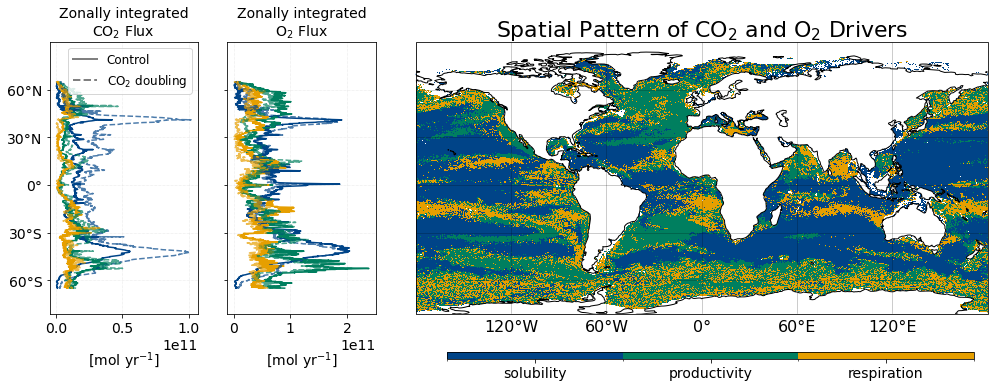

In [9]:
#plotting the whole categorization
fig = plt.figure(figsize=(17,5),layout='compressed')
plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":14,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})
gs = gridspec.GridSpec(1, 3, width_ratios=[1,1,4], wspace=.1, hspace=.1)
ax1 = fig.add_subplot(gs[2],projection=ccrs.PlateCarree(central_longitude=0))
#ax2 = fig.add_subplot(gs[2],projection=ccrs.PlateCarree(central_longitude=0))

#
#
im1=combined_mask_ctrl.plot(ax=ax1, x='geolon_t', y='geolat_t',cmap=cm,norm=norm, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})

#im2=combined_mask_cc.plot(ax=ax2, x='geolon_t', y='geolat_t',cmap=cm,norm=norm, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})

axs=[ax1]#,ax2
for i in axs:
        gl = i.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                              linewidth=1, color='black', alpha=0.2)
        gl.xlabels_top = False
        gl.ylabels_left = False
        i.coastlines()
        if i==ax1:
            gl.ylabels_right=False
#

####LINEPLOTS
ax0 = fig.add_subplot(gs[0])
ax01 = fig.add_subplot(gs[1])

#CO2
co2_sol.where((co2_sol.yt_ocean<=65) & (co2_sol.yt_ocean >=-65)).plot(ax=ax0, c='#004488',y='yt_ocean')
co2_bio.where((co2_bio.yt_ocean<=65) & (co2_bio.yt_ocean >=-65)).plot(ax=ax0, c='#007F5F',y='yt_ocean')
co2_res.where((co2_res.yt_ocean<=65) & (co2_res.yt_ocean >=-65)).plot(ax=ax0, c='#E69F00',y='yt_ocean')

co2_sol_cc.where((co2_sol_cc.yt_ocean<=65) & (co2_sol_cc.yt_ocean >=-65)).plot(ax=ax0, c='#004488',y='yt_ocean', linestyle='--', alpha=0.7)
co2_bio_cc.where((co2_bio_cc.yt_ocean<=65) & (co2_bio_cc.yt_ocean >=-65)).plot(ax=ax0, c='#007F5F',y='yt_ocean', linestyle='--', alpha=0.7)
co2_res_cc.where((co2_res_cc.yt_ocean<=65) & (co2_res_cc.yt_ocean >=-65)).plot(ax=ax0, c='#E69F00',y='yt_ocean', linestyle='--', alpha=0.7)


#O2
o2_sol.where((o2_sol.yt_ocean<=65) & (o2_sol.yt_ocean >=-65)).plot(ax=ax01, c='#004488',y='yt_ocean')
o2_bio.where((o2_bio.yt_ocean<=65) & (o2_bio.yt_ocean >=-65)).plot(ax=ax01, c='#007F5F',y='yt_ocean')
o2_res.where((o2_res.yt_ocean<=65) & (o2_res.yt_ocean >=-65)).plot(ax=ax01, c='#E69F00',y='yt_ocean')

o2_sol_cc.where((o2_sol_cc.yt_ocean<=65) & (o2_sol_cc.yt_ocean >=-65)).plot(ax=ax01, c='#004488',y='yt_ocean', linestyle='--', alpha=0.7)
o2_bio_cc.where((o2_bio_cc.yt_ocean<=65) & (o2_bio_cc.yt_ocean >=-65)).plot(ax=ax01, c='#007F5F',y='yt_ocean', linestyle='--', alpha=0.7)
o2_res_cc.where((o2_res_cc.yt_ocean<=65) & (o2_res_cc.yt_ocean >=-65)).plot(ax=ax01, c='#E69F00',y='yt_ocean', linestyle='--', alpha=0.7)


ticks = [0, 30, 60, -30, -60]  # latitudes
labels_y = ['0°', '30°N', '60°N', '30°S', '60°S']

for ax in [ax0, ax01]:
    ax.set_ylim([-81.108632,89.978896])
    ax.grid(c='lightgray', linewidth=.5, linestyle='dotted')
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels_y)
    ax.set_ylabel('')
    ax.set_xlabel('[mol yr$^{-1}$]',labelpad=15);

ax01.set_yticklabels([])


###TITLES AND LABELS
ax0.set_title('Zonally integrated\nCO$_2$ Flux', fontsize=14)
ax01.set_title('Zonally integrated\nO$_2$ Flux', fontsize=14)

legend_elements = [
    Line2D([0], [0], color='gray', lw=2, linestyle='-', label='Control'),
    Line2D([0], [0], color='gray', lw=2, linestyle='--', label='CO$_2$ doubling')
]

ax0.legend(handles=legend_elements, fontsize=12)
ax1.set_title('Spatial Pattern of CO$_2$ and O$_2$ Drivers')
diff = norm_bins[1:] - norm_bins[:-1]
tickz = norm_bins[:-1] + diff / 2
cbar_ax = fig.add_axes([0.45, 0, 0.43, 0.02])
cb = fig.colorbar(im1, cax=cbar_ax,orientation='horizontal', format=fmt, ticks=tickz);
cb.ax.tick_params(labelsize=14)

plt.savefig(pathp+'Categorization_final.png', dpi=300, bbox_inches='tight');

# 1PctTo2X for SI

In [10]:
area_grid=grid.area_t
area_grid_sol=area_grid.where(combined_mask_ctrl==1).sum(dim='xt_ocean')
area_grid_pro=area_grid.where(combined_mask_ctrl==2).sum(dim='xt_ocean')
area_grid_res=area_grid.where(combined_mask_ctrl==3).sum(dim='xt_ocean')
area_grid_sol_cc=area_grid.where(combined_mask_cc==1).sum(dim='xt_ocean')
area_grid_pro_cc=area_grid.where(combined_mask_cc==2).sum(dim='xt_ocean')
area_grid_res_cc=area_grid.where(combined_mask_cc==3).sum(dim='xt_ocean')

lat_true = dsa.geolat_t.mean(dim='xt_ocean')

area_grid_sol = area_grid_sol.assign_coords(yt_ocean=lat_true)
area_grid_pro = area_grid_pro.assign_coords(yt_ocean=lat_true)
area_grid_res = area_grid_res.assign_coords(yt_ocean=lat_true)
area_grid_sol_cc = area_grid_sol_cc.assign_coords(yt_ocean=lat_true)
area_grid_pro_cc = area_grid_pro_cc.assign_coords(yt_ocean=lat_true)
area_grid_res_cc = area_grid_res_cc.assign_coords(yt_ocean=lat_true)

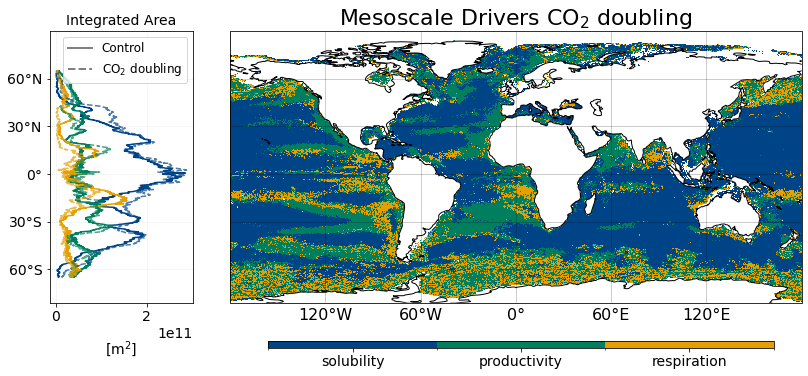

In [11]:
#plotting the whole categorization
fig = plt.figure(figsize=(13.5,5),layout='compressed')
plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":22,
    "axes.labelsize":14,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})
gs = gridspec.GridSpec(1, 2, width_ratios=[1,4], wspace=.1, hspace=.1)
ax1 = fig.add_subplot(gs[1],projection=ccrs.PlateCarree(central_longitude=0))
#ax2 = fig.add_subplot(gs[2],projection=ccrs.PlateCarree(central_longitude=0))

#
#
im1=combined_mask_cc.plot(ax=ax1, x='geolon_t', y='geolat_t',cmap=cm,norm=norm, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})

#im2=combined_mask_cc.plot(ax=ax2, x='geolon_t', y='geolat_t',cmap=cm,norm=norm, transform=ccrs.PlateCarree(), add_colorbar=False)#, cbar_kwargs={'orientation':'horizontal','label': "mean CO2 flux [mmol/m^2*yr]"})

axs=[ax1]#,ax2
for i in axs:
        gl = i.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                              linewidth=1, color='black', alpha=0.2)
        gl.xlabels_top = False
        gl.ylabels_left = False
        i.coastlines()
        if i==ax1:
            gl.ylabels_right=False
#

####LINEPLOTS
ax0 = fig.add_subplot(gs[0])

#CO2
area_grid_sol.where((area_grid_sol.yt_ocean<=65) & (area_grid_sol.yt_ocean >=-65)).plot(ax=ax0, c='#004488',y='yt_ocean')
area_grid_pro.where((area_grid_pro.yt_ocean<=65) & (area_grid_pro.yt_ocean >=-65)).plot(ax=ax0, c='#007F5F',y='yt_ocean')
area_grid_res.where((area_grid_res.yt_ocean<=65) & (area_grid_res.yt_ocean >=-65)).plot(ax=ax0, c='#E69F00',y='yt_ocean')

area_grid_sol_cc.where((area_grid_sol_cc.yt_ocean<=65) & (area_grid_sol_cc.yt_ocean >=-65)).plot(ax=ax0, c='#004488',y='yt_ocean', linestyle='--', alpha=0.7)
area_grid_pro_cc.where((area_grid_pro_cc.yt_ocean<=65) & (area_grid_pro_cc.yt_ocean >=-65)).plot(ax=ax0, c='#007F5F',y='yt_ocean', linestyle='--', alpha=0.7)
area_grid_res_cc.where((area_grid_res_cc.yt_ocean<=65) & (area_grid_res_cc.yt_ocean >=-65)).plot(ax=ax0, c='#E69F00',y='yt_ocean', linestyle='--', alpha=0.7)

ax0.grid(c='lightgray', linewidth=.5, linestyle='dotted')
ax0.set_yticks([-60,-30,0,30,60])
ax0.set_ylim([-81.108632,89.978896])

###TITLES AND LABELS
ax0.set_title('Integrated Area', fontsize=14)
ax1.set_title('Mesoscale Drivers CO$_2$ doubling')
ticks = [0, 30, 60, -30, -60]  # latitudes
labels_y = ['0°', '30°N', '60°N', '30°S', '60°S']
ax0.set_yticks(ticks)
ax0.set_yticklabels(labels_y)
ax0.set_xlabel('[m$^{2}$]',labelpad=15);
ax0.set_ylabel('')
diff = norm_bins[1:] - norm_bins[:-1]
tickz = norm_bins[:-1] + diff / 2
cbar_ax = fig.add_axes([0.35, 0, 0.52, 0.02])
cb = fig.colorbar(im1, cax=cbar_ax,orientation='horizontal', format=fmt, ticks=tickz);
#plt.suptitle('Mesoscale Drivers', fontsize=21, y=1.07);
cb.ax.tick_params(labelsize=14)
legend_elements = [
    Line2D([0], [0], color='gray', lw=2, linestyle='-', label='Control'),
    Line2D([0], [0], color='gray', lw=2, linestyle='--', label='CO$_2$ doubling')
]

ax0.legend(handles=legend_elements, fontsize=12)

plt.savefig(pathp+'Categorization_final_SI.png', dpi=300, bbox_inches='tight');